# Dataset exploration

In [1]:
import netCDF4 as nc
import xarray as xr
import numpy as np
import torch
from torch_geometric.data import Data

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask.distributed import Client, LocalCluster, as_completed
from dask import delayed, compute
import imageio
import tempfile
from tqdm import tqdm
import dask
import gc
import random
import seaborn as sns

## Dataset Loading

In [2]:
import os

In [3]:
dataset_base_directory = os.curdir+os.sep+"dataset"
dataset_files = dataset_base_directory+os.sep+'*.nc4'

In [4]:
dask.config.set(scheduler='threads') 
lat_min, lat_max = 30, 60
lon_min, lon_max = 0, 30
time_window = 20
gif_filename = "temperature_animation.gif"

dataset_base_directory = os.curdir+os.sep+"dataset"
dataset_files = dataset_base_directory+os.sep+'*.nc4'

ds = xr.open_mfdataset(dataset_files, cache=False)
ds

<xarray.Dataset> Size: 745GB
Dimensions:  (time: 5708, lat: 3298, lon: 9896)
Coordinates:
  * lon      (lon) float32 40kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat      (lat) float32 13kB -59.98 -59.95 -59.91 ... 59.91 59.95 59.98
  * time     (time) datetime64[ns] 46kB 2020-01-01 ... 2020-04-28T21:30:00.00...
Data variables:
    Tb       (time, lat, lon) float32 745GB dask.array<chunksize=(1, 1649, 2474), meta=np.ndarray>
Attributes:
    BeginDate:       2020-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2020-01-01
    EndTime:         00:59:59.999Z
    FileHeader:      StartGranuleDateTime=2020-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    merg_2020010100_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2020-01-03T00:19:23.203Z

In [5]:
ds = ds.sel(
    lat=slice(lat_min, lat_max), 
    lon=slice(lon_min, lon_max) 
)
ds = ds.chunk({'time': time_window})
ds['Tb'] = ds['Tb'].astype('float16')

In [6]:
# Select a subset of time steps for visualization
t1 = random.randint(0,ds['time'].shape[0]-time_window)


In [7]:
from gif_generation import generate_gif
from IPython.display import HTML

In [14]:
ani = generate_gif(ds, t1, time_window)
HTML(ani.to_jshtml())

Generating GIF: 100%|██████████| 20/20 [00:25<00:00,  1.27s/it]


Since the dataset is really large, it was subsampled to the geographical zone comprising Europe and Africa

## Dataset exploration

In [9]:

Tb = ds.variables['Tb'][:]     
lat = ds.variables['lat'][:]      
lon = ds.variables['lon'][:]     
time = ds.variables['time'][:]    

print("Shapes: Tb:", Tb.shape, "lat:", lat.shape, "lon:", lon.shape, "time:", time.shape)

Shapes: Tb: (5708, 825, 825) lat: (825,) lon: (825,) time: (5708,)


###  Explore Missing Values

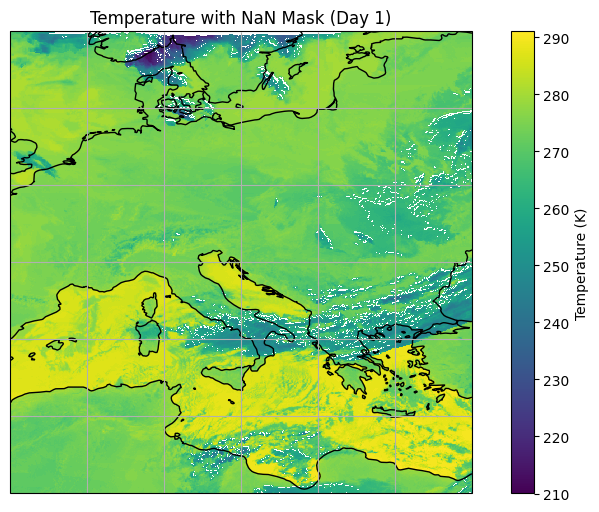

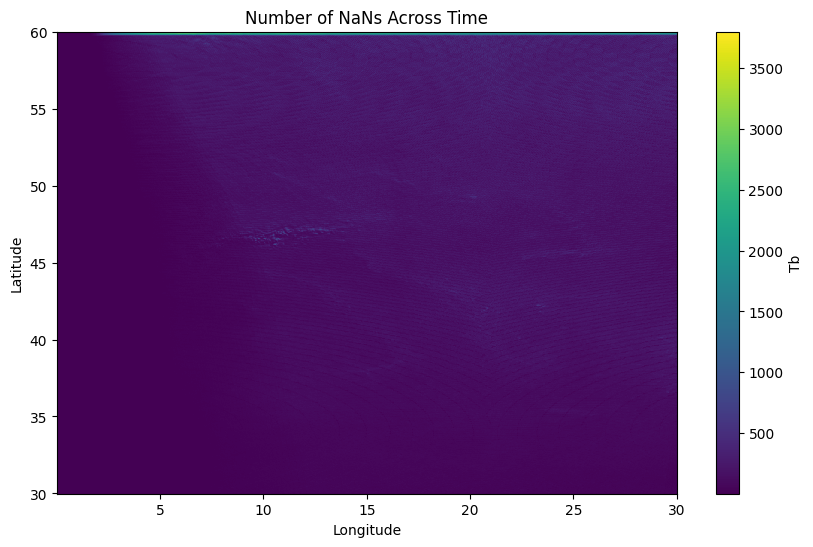

In [ ]:
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ds['Tb'].isel(time=0).plot(
    ax=ax, x='lon', y='lat', 
    transform=ccrs.PlateCarree(), 
    cbar_kwargs={'label': 'Temperature (K)'}
)
ax.coastlines()
ax.gridlines()
plt.title("Temperature with NaN Mask (Day 1)")
plt.show()

nan_counts = ds['Tb'].isnull().sum(dim='time')

plt.figure(figsize=(10, 6))
nan_counts.plot(cmap='viridis', x='lon', y='lat')
plt.title("Number of NaNs Across Time")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Distribution of temperature values

In [11]:

temp_data = ds.isel(time=slice(t1, t1+time_window))
temp_data = temp_data['Tb'].values.flatten()
temp_data = temp_data[~np.isnan(temp_data)]  # Remove NaNs

print(f"Mean: {np.mean(temp_data):.2f} K")
print(f"Min: {np.min(temp_data):.2f} K")
print(f"Max: {np.max(temp_data):.2f} K")

Mean: 268.00 K
Min: 219.00 K
Max: 302.00 K


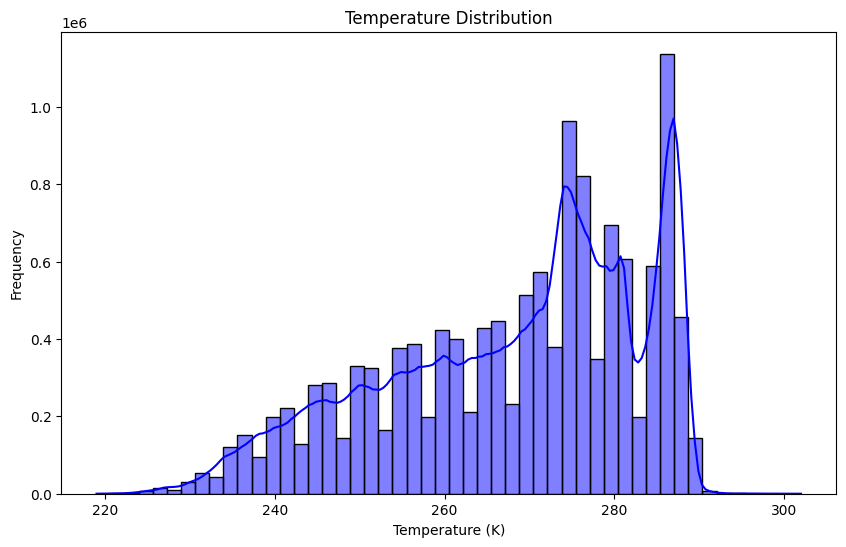

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(temp_data, bins=50, kde=True, color='blue')
plt.title("Temperature Distribution")
plt.xlabel("Temperature (K)")
plt.ylabel("Frequency")
plt.show()

## Temporal correlation between pixels

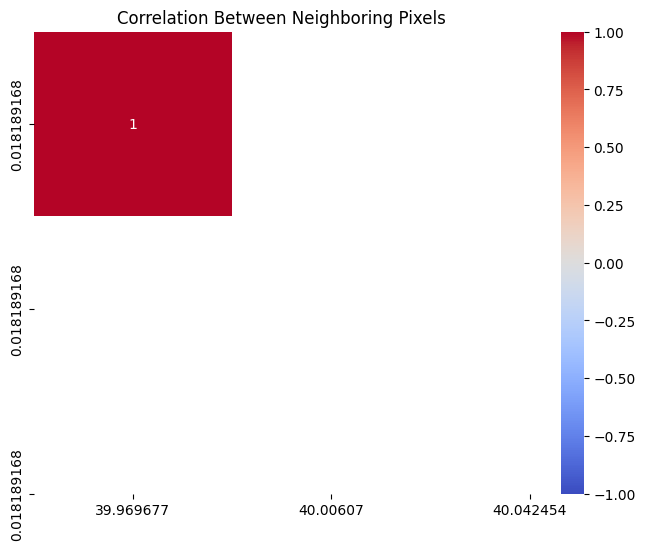

In [ ]:
central_lat = 40.0
central_lon = -95.0
temp_series = ds['Tb'].sel(
    lat=central_lat, 
    lon=central_lon, 
    method='nearest'
)

neighbors = ds['Tb'].sel(
    lat=[central_lat - 0.04, central_lat, central_lat + 0.04],  
    lon=[central_lon - 0.04, central_lon, central_lon + 0.04],
    method='nearest'
)

correlation_matrix = neighbors.to_dataframe().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    xticklabels=neighbors.coords['lat'].values,
    yticklabels=neighbors.coords['lon'].values
)
plt.title("Correlation Between Neighboring Pixels")
plt.show()